In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from agent.eval.realtime_chunking import RealtimeActionChunkingBuffer

In [ ]:
debug = pickle.load(open('bedug-rca.pkl', 'rb'))
env_t0, robs = pickle.load(open('bedrug-robs.pkl', 'rb'))
acts = pickle.load(open('bedug-acts.pkl', 'rb'))

chunks = [d['chunk'] for d in debug]
obs = [d['obs'] for d in debug]
t_proc = np.array([d['t'] for d in debug])

t_act = np.array([a[0] for a in acts])
eval_acts = np.array([a[1][0] for a in acts])

t0 = t_proc[0]
buf = RealtimeActionChunkingBuffer(1/5, weight_decay=10)

In [135]:
# redo action buffer -> actions
actions = []
ix = 0
buf._chunks = []
act_ts = t_act - t0
for t in act_ts:
    if t + t0 >= t_proc[ix]:
        buf._chunks.append(chunks[ix])
        ix += 1
    act, _ = buf.get_action(t + t0)
    actions.append(act)
actions = np.array(actions)

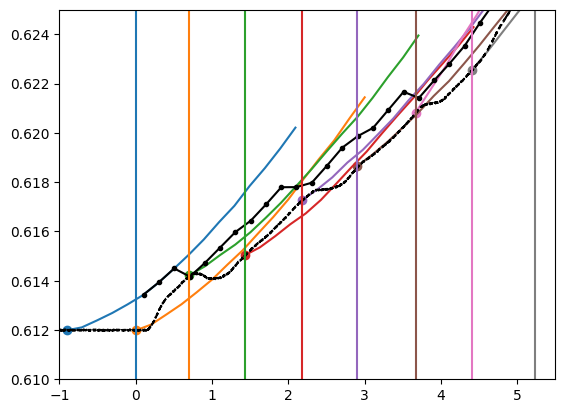

In [136]:
ix = 1
actual = np.array([(env_t0 + ri.time, ri.actual_pose[ix]) for ri in robs])

for i in range(0,10):
    plt.scatter(chunks[i].times[0] - t0, chunks[i].poses[0, ix])
    plt.plot(chunks[i].times - t0, chunks[i].poses[:, ix])

plt.plot(actual[:, 0] - t0, actual[:, ix], 'k--')

plt.plot(act_ts, actions[:, ix], 'k.-')
# plt.plot(t_act - t0, eval_acts[:, ix], 'k.-')

plt.xlim(-1, 5.5)
plt.ylim(.61, .625)

for i in range(0,10):
    plt.vlines(t_proc[i] - t0, -1, 1, f'C{i}')


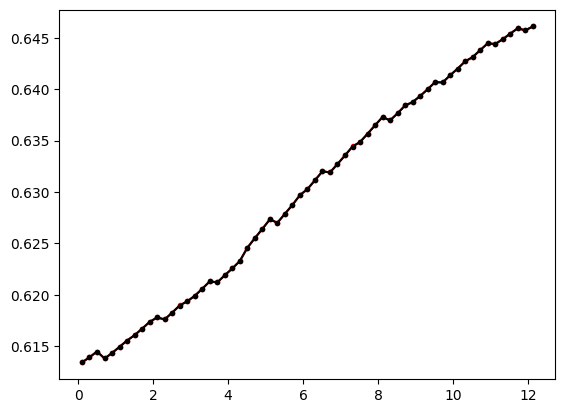

In [129]:
plt.plot(act_ts, actions[:, ix], 'r.-')
plt.plot(t_act - t0, eval_acts[:, ix], 'k.-')
